# Testing Initial Guess Behaviour on Noise-Only Data

**Question:** Does `initial_guess()` overestimate photon counts for blank / noise-only regions?

**Motivation:** We observe fitted puncta with relatively high photon counts in areas with no visible structure. This suggests the initial guess may bias the LM fitter towards non-zero amplitudes, preventing it from converging to ~0 photons.

**Approach:**
1. Generate synthetic noise-only patches (Poisson + read noise, realistic sCMOS)
2. Run `initial_guess()` and examine the amplitude estimates
3. Run the full WLS fitter from these initial guesses and check fitted photon counts
4. Compare with patches containing a real (weak) Gaussian spot
5. Quantify the bias as a function of background level and noise

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt


from pyS3M import gaussoptfuncs
from pyS3M.MaskFunctions import Mask_Functions
from scipy.optimize import leastsq

## 1. Setup: Generate Bayer masks and smoothing kernel

In [2]:
ROI_size = 16  # standard punctum size

# Generate Bayer masks
mf = Mask_Functions()
masks_dict = mf.get_masks(ROI_size, ROI_size)
masks_3d = np.dstack([masks_dict[c] for c in ["B", "G", "R"]])

# Smoothing kernel (Gaussian, sigma ~ 1.5 px, matching typical spot detection)
from scipy.ndimage import gaussian_filter

def smooth_punctum(data, sigma=1.5):
    """Replicate the smoothing applied before initial_guess."""
    return gaussian_filter(data.astype(np.float64), sigma=sigma).astype(np.float32)

print(f"ROI size: {ROI_size}x{ROI_size}")
print(f"Mask shape: {masks_3d.shape}")
print(f"Blue pixels: {masks_3d[:,:,0].sum()}, Green: {masks_3d[:,:,1].sum()}, Red: {masks_3d[:,:,2].sum()}")

ROI size: 16x16
Mask shape: (16, 16, 3)
Blue pixels: 64, Green: 128, Red: 64


## 2. Generate noise-only patches

Simulate realistic sCMOS noise: Poisson shot noise on a flat background + Gaussian read noise.

In [3]:
def generate_noise_patch(bg_level, read_noise_std, size=16, rng=None):
    """Generate a noise-only patch (no signal).
    
    Args:
        bg_level: Mean background in photoelectrons
        read_noise_std: Read noise standard deviation (photoelectrons)
        size: Patch size in pixels
        rng: numpy random generator
    
    Returns:
        patch in photoelectrons (float32)
    """
    if rng is None:
        rng = np.random.default_rng()
    shot = rng.poisson(bg_level, size=(size, size)).astype(np.float32)
    read = rng.normal(0, read_noise_std, size=(size, size)).astype(np.float32)
    return shot + read


def generate_spot_patch(bg_level, read_noise_std, amplitude, sigma_spot=1.3,
                        size=16, rng=None):
    """Generate a patch with a Gaussian spot + noise.
    
    Args:
        bg_level: Mean background in photoelectrons
        read_noise_std: Read noise standard deviation
        amplitude: Peak amplitude of spot (photoelectrons)
        sigma_spot: Gaussian sigma in pixels
        size: Patch size
        rng: numpy random generator
    
    Returns:
        patch in photoelectrons (float32)
    """
    if rng is None:
        rng = np.random.default_rng()
    y, x = np.mgrid[:size, :size]
    cx, cy = size / 2.0, size / 2.0
    spot = amplitude * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma_spot**2))
    mean_image = bg_level + spot
    shot = rng.poisson(np.clip(mean_image, 0, None)).astype(np.float32)
    read = rng.normal(0, read_noise_std, size=(size, size)).astype(np.float32)
    return shot + read

## 3. Test initial guess on noise-only patches

Run `initial_guess()` on many noise-only patches and examine the amplitude estimates.

In [4]:
rng = np.random.default_rng(42)
n_trials = 1000
bg_level = 50  # typical background (photoelectrons)
read_noise_std = 2.0  # typical sCMOS read noise

ig_amplitudes = []  # initial guess amplitude (squared, since model squares params)
ig_total_photons = []  # sum of A_B + A_G + A_R from initial guess

for _ in range(n_trials):
    patch = generate_noise_patch(bg_level, read_noise_std, ROI_size, rng)
    smoothed = smooth_punctum(patch)
    
    ig = gaussoptfuncs.initial_guess(smoothed, patch, masks_3d)
    # ig[7], ig[8], ig[9] are sqrt(A_B), sqrt(A_G), sqrt(A_R)
    A_B = ig[7]**2
    A_G = ig[8]**2
    A_R = ig[9]**2
    ig_amplitudes.append([A_B, A_G, A_R])
    ig_total_photons.append(A_B + A_G + A_R)

ig_amplitudes = np.array(ig_amplitudes)
ig_total_photons = np.array(ig_total_photons)

print(f"=== Initial guess on NOISE-ONLY patches (bg={bg_level} pe, n={n_trials}) ===")
print(f"Total photon estimate (A_B+A_G+A_R):")
print(f"  Mean:   {ig_total_photons.mean():.1f}")
print(f"  Median: {np.median(ig_total_photons):.1f}")
print(f"  Std:    {ig_total_photons.std():.1f}")
print(f"  Min:    {ig_total_photons.min():.1f}")
print(f"  Max:    {ig_total_photons.max():.1f}")
print(f"\nPer-channel (A_B, A_G, A_R):")
for i, ch in enumerate(["Blue", "Green", "Red"]):
    print(f"  {ch}: {ig_amplitudes[:, i].mean():.1f} +/- {ig_amplitudes[:, i].std():.1f}")
print(f"\nTrue signal: 0 photons (noise only)")

=== Initial guess on NOISE-ONLY patches (bg=50 pe, n=1000) ===
Total photon estimate (A_B+A_G+A_R):
  Mean:   1036.5
  Median: 992.6
  Std:    255.7
  Min:    520.6
  Max:    2838.2

Per-channel (A_B, A_G, A_R):
  Blue: 345.5 +/- 85.2
  Green: 345.5 +/- 85.2
  Red: 345.5 +/- 85.2

True signal: 0 photons (noise only)


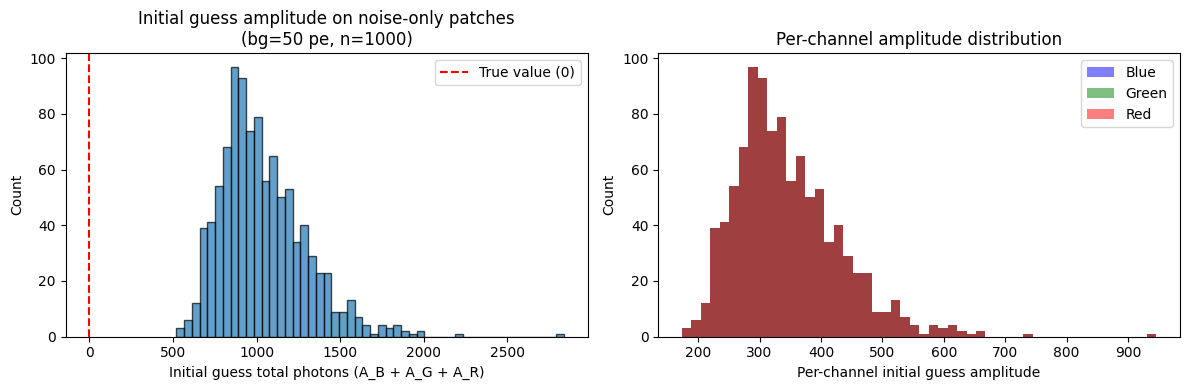

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ig_total_photons, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='True value (0)')
axes[0].set_xlabel('Initial guess total photons (A_B + A_G + A_R)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Initial guess amplitude on noise-only patches\n(bg={bg_level} pe, n={n_trials})')
axes[0].legend()

for i, (ch, color) in enumerate(zip(['Blue', 'Green', 'Red'], ['blue', 'green', 'red'])):
    axes[1].hist(ig_amplitudes[:, i], bins=50, alpha=0.5, label=ch, color=color)
axes[1].set_xlabel('Per-channel initial guess amplitude')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-channel amplitude distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Run full WLS fit on noise-only patches

Does the LM fitter recover ~0 photons from the (biased) initial guess, or does it get stuck?

In [6]:
def fit_patch(patch, smoothed, masks_3d):
    """Run the full WLS fit on a patch, returning fitted parameters.
    
    Returns:
        dict with keys: A_B, A_G, A_R, total_photons, chi_sqr, success,
                        ig_A_B, ig_A_G, ig_A_R, ig_total
        or None if fit fails completely.
    """
    size = patch.shape[0]
    ravelsize = size * size
    
    ig = gaussoptfuncs.initial_guess(smoothed, patch, masks_3d)
    ig = np.array(ig, dtype=np.float64)
    
    # Weights: inverse variance (Poisson + read noise)
    weights = 1.0 / np.sqrt(np.abs(patch) + read_noise_std**2 + 1.0)
    weights = weights.astype(np.float32)
    
    try:
        pfit, pcov, infodict, errmsg, success = leastsq(
            gaussoptfuncs.WLS_chi_nobounds,
            x0=ig,
            args=(patch.astype(np.float32), masks_3d, weights, size, ravelsize),
            full_output=True,
            ftol=1e-6,
            xtol=1e-6,
        )
        
        # Fitted amplitudes (model squares them)
        A_B = pfit[7]**2
        A_G = pfit[8]**2
        A_R = pfit[9]**2
        
        # Chi-squared
        residuals = gaussoptfuncs.WLS_chi_nobounds(
            pfit, patch.astype(np.float32), masks_3d, weights, size, ravelsize
        )
        chi_sqr = np.sum(residuals**2) / (ravelsize - len(ig))
        
        return {
            'A_B': A_B, 'A_G': A_G, 'A_R': A_R,
            'total_photons': A_B + A_G + A_R,
            'chi_sqr': chi_sqr,
            'success': success,
            'ig_A_B': ig[7]**2, 'ig_A_G': ig[8]**2, 'ig_A_R': ig[9]**2,
            'ig_total': ig[7]**2 + ig[8]**2 + ig[9]**2,
            'sigma_x': pfit[2]**2 if pfit[2] > 0 else pfit[2],
            'sigma_y': pfit[3]**2 if pfit[3] > 0 else pfit[3],
        }
    except Exception as e:
        return None

In [7]:
rng = np.random.default_rng(42)
n_trials = 500

noise_results = []
for _ in range(n_trials):
    patch = generate_noise_patch(bg_level, read_noise_std, ROI_size, rng)
    smoothed = smooth_punctum(patch)
    result = fit_patch(patch, smoothed, masks_3d)
    if result is not None:
        noise_results.append(result)

fitted_photons_noise = np.array([r['total_photons'] for r in noise_results])
ig_photons_noise = np.array([r['ig_total'] for r in noise_results])
chi_sqr_noise = np.array([r['chi_sqr'] for r in noise_results])

print(f"=== FITTED results on NOISE-ONLY patches (n={len(noise_results)}) ===")
print(f"\nInitial guess total photons:")
print(f"  Mean: {ig_photons_noise.mean():.1f}, Median: {np.median(ig_photons_noise):.1f}")
print(f"\nFitted total photons:")
print(f"  Mean: {fitted_photons_noise.mean():.1f}, Median: {np.median(fitted_photons_noise):.1f}")
print(f"  Std:  {fitted_photons_noise.std():.1f}")
print(f"  Min:  {fitted_photons_noise.min():.1f}, Max: {fitted_photons_noise.max():.1f}")
print(f"\nReduced chi-squared:")
print(f"  Mean: {chi_sqr_noise.mean():.3f}, Median: {np.median(chi_sqr_noise):.3f}")
print(f"\nTrue signal: 0 photons")

=== FITTED results on NOISE-ONLY patches (n=500) ===

Initial guess total photons:
  Mean: 1036.3, Median: 991.3

Fitted total photons:
  Mean: 6958752.9, Median: 817.3
  Std:  153292305.4
  Min:  0.1, Max: 3431224498.5

Reduced chi-squared:
  Mean: 7.239, Median: 7.246

True signal: 0 photons


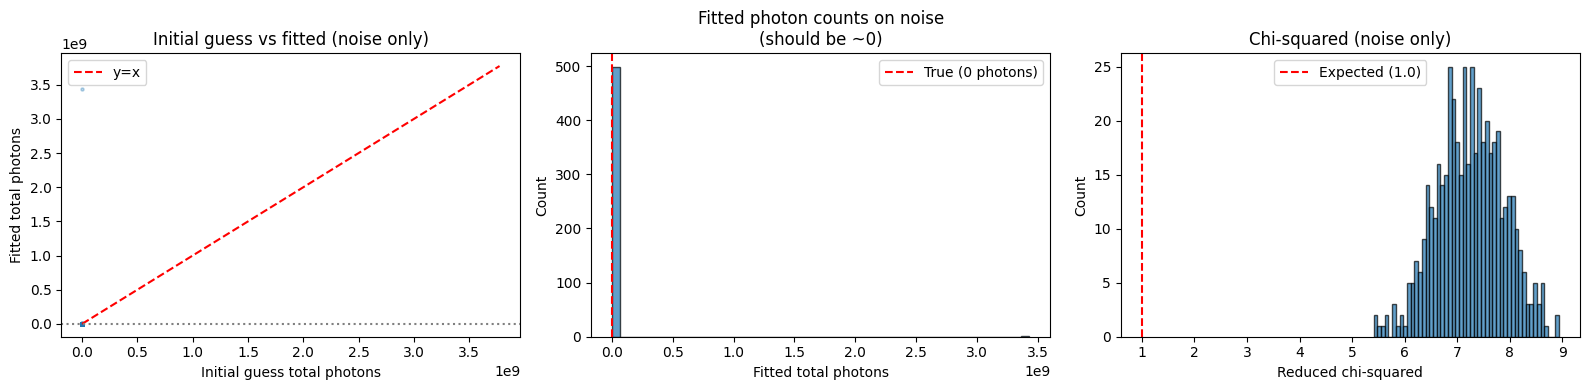

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Fitted vs initial guess photons
axes[0].scatter(ig_photons_noise, fitted_photons_noise, alpha=0.3, s=5)
lim = max(ig_photons_noise.max(), fitted_photons_noise.max()) * 1.1
axes[0].plot([0, lim], [0, lim], 'r--', label='y=x')
axes[0].axhline(0, color='grey', linestyle=':')
axes[0].set_xlabel('Initial guess total photons')
axes[0].set_ylabel('Fitted total photons')
axes[0].set_title('Initial guess vs fitted (noise only)')
axes[0].legend()

# Histogram of fitted photons
axes[1].hist(fitted_photons_noise, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='True (0 photons)')
axes[1].set_xlabel('Fitted total photons')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Fitted photon counts on noise\n(should be ~0)')
axes[1].legend()

# Chi-squared distribution
axes[2].hist(chi_sqr_noise, bins=50, edgecolor='black', alpha=0.7)
axes[2].axvline(1.0, color='red', linestyle='--', label='Expected (1.0)')
axes[2].set_xlabel('Reduced chi-squared')
axes[2].set_ylabel('Count')
axes[2].set_title('Chi-squared (noise only)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Compare: noise-only vs weak spots

Fit patches with real (weak) Gaussian spots and compare with noise-only results.

In [ ]:
rng = np.random.default_rng(42)
spot_amplitudes = [0, 10, 25, 50, 100, 200, 500]  # peak amplitude in photoelectrons

results_by_amplitude = {}

for amp in spot_amplitudes:
    results = []
    for _ in range(200):
        if amp == 0:
            patch = generate_noise_patch(bg_level, read_noise_std, ROI_size, rng)
        else:
            patch = generate_spot_patch(bg_level, read_noise_std, amp,
                                        sigma_spot=1.3, size=ROI_size, rng=rng)
        smoothed = smooth_punctum(patch)
        result = fit_patch(patch, smoothed, masks_3d)
        if result is not None:
            results.append(result)
    results_by_amplitude[amp] = results
    
    fitted = np.array([r['total_photons'] for r in results])
    ig = np.array([r['ig_total'] for r in results])
    print(f"Amplitude={amp:4d} pe | IG: {ig.mean():8.1f} +/- {ig.std():6.1f} | "
          f"Fitted: {fitted.mean():8.1f} +/- {fitted.std():6.1f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of initial guess vs true amplitude
ig_data = [np.array([r['ig_total'] for r in results_by_amplitude[a]]) for a in spot_amplitudes]
fit_data = [np.array([r['total_photons'] for r in results_by_amplitude[a]]) for a in spot_amplitudes]

bp1 = axes[0].boxplot(ig_data, positions=np.arange(len(spot_amplitudes)),
                       widths=0.35, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
axes[0].set_xticks(range(len(spot_amplitudes)))
axes[0].set_xticklabels([str(a) for a in spot_amplitudes])
axes[0].set_xlabel('True spot amplitude (pe)')
axes[0].set_ylabel('Initial guess total photons')
axes[0].set_title('Initial guess vs true amplitude')
axes[0].axhline(0, color='grey', linestyle=':')

bp2 = axes[1].boxplot(fit_data, positions=np.arange(len(spot_amplitudes)),
                       widths=0.35, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightsalmon')
axes[1].set_xticks(range(len(spot_amplitudes)))
axes[1].set_xticklabels([str(a) for a in spot_amplitudes])
axes[1].set_xlabel('True spot amplitude (pe)')
axes[1].set_ylabel('Fitted total photons')
axes[1].set_title('Fitted photons vs true amplitude')
axes[1].axhline(0, color='grey', linestyle=':')

plt.tight_layout()
plt.show()

## 6. Effect of background level

Higher backgrounds mean more Poisson noise → larger amplitude bias in the initial guess.

In [9]:
rng = np.random.default_rng(42)
bg_levels = [10, 25, 50, 100, 200, 500]

ig_by_bg = {}
fit_by_bg = {}

for bg in bg_levels:
    ig_photons = []
    fit_photons = []
    for _ in range(300):
        patch = generate_noise_patch(bg, read_noise_std, ROI_size, rng)
        smoothed = smooth_punctum(patch)
        
        ig = gaussoptfuncs.initial_guess(smoothed, patch, masks_3d)
        ig_total = ig[7]**2 + ig[8]**2 + ig[9]**2
        ig_photons.append(ig_total)
        
        result = fit_patch(patch, smoothed, masks_3d)
        if result is not None:
            fit_photons.append(result['total_photons'])
    
    ig_by_bg[bg] = np.array(ig_photons)
    fit_by_bg[bg] = np.array(fit_photons)
    
    print(f"bg={bg:4d} pe | IG mean: {ig_by_bg[bg].mean():8.1f} | "
          f"Fitted mean: {fit_by_bg[bg].mean():8.1f} +/- {fit_by_bg[bg].std():.1f}")

bg=  10 pe | IG mean:    528.6 | Fitted mean: 153269.0 +/- 1186695.1
bg=  25 pe | IG mean:    759.2 | Fitted mean: 597427.1 +/- 6607977.8
bg=  50 pe | IG mean:   1050.6 | Fitted mean:  83554.9 +/- 989387.3
bg= 100 pe | IG mean:   1417.3 | Fitted mean: 129536.1 +/- 926736.5
bg= 200 pe | IG mean:   2056.7 | Fitted mean: 131967.0 +/- 1017477.3
bg= 500 pe | IG mean:   3166.6 | Fitted mean:  62097.6 +/- 581859.3


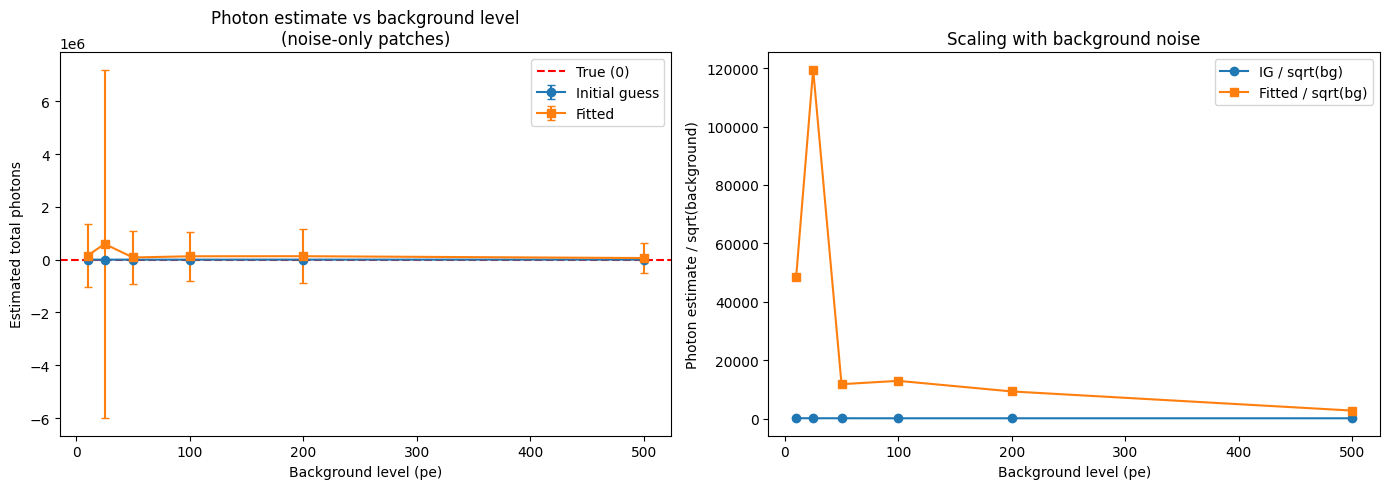

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ig_means = [ig_by_bg[bg].mean() for bg in bg_levels]
ig_stds = [ig_by_bg[bg].std() for bg in bg_levels]
fit_means = [fit_by_bg[bg].mean() for bg in bg_levels]
fit_stds = [fit_by_bg[bg].std() for bg in bg_levels]

axes[0].errorbar(bg_levels, ig_means, yerr=ig_stds, fmt='o-', label='Initial guess', capsize=3)
axes[0].errorbar(bg_levels, fit_means, yerr=fit_stds, fmt='s-', label='Fitted', capsize=3)
axes[0].axhline(0, color='red', linestyle='--', label='True (0)')
axes[0].set_xlabel('Background level (pe)')
axes[0].set_ylabel('Estimated total photons')
axes[0].set_title('Photon estimate vs background level\n(noise-only patches)')
axes[0].legend()

# Normalised: photon estimate / sqrt(background)
axes[1].plot(bg_levels, [m / np.sqrt(bg) for m, bg in zip(ig_means, bg_levels)],
             'o-', label='IG / sqrt(bg)')
axes[1].plot(bg_levels, [m / np.sqrt(bg) for m, bg in zip(fit_means, bg_levels)],
             's-', label='Fitted / sqrt(bg)')
axes[1].set_xlabel('Background level (pe)')
axes[1].set_ylabel('Photon estimate / sqrt(background)')
axes[1].set_title('Scaling with background noise')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Visualise a single noise patch through the pipeline

Step through one example to see exactly what happens.

In [ ]:
rng = np.random.default_rng(123)
patch = generate_noise_patch(bg_level, read_noise_std, ROI_size, rng)
smoothed = smooth_punctum(patch)

ig = gaussoptfuncs.initial_guess(smoothed, patch, masks_3d)
ig = np.array(ig, dtype=np.float64)

# Background-subtracted smoothed data (what initial_guess sees)
ig_data = np.abs(smoothed)
bs_data = ig_data - np.abs(np.min(ig_data))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

im0 = axes[0].imshow(patch, origin='lower')
axes[0].set_title(f'Raw patch\n(bg={bg_level}, noise only)')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(smoothed, origin='lower')
axes[1].set_title('Smoothed')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(bs_data, origin='lower')
axes[2].set_title(f'BG-subtracted (min removed)\nSum = {bs_data.sum():.1f}')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

# Show the model from initial guess
x = np.arange(ROI_size, dtype=np.float32)
gauss_2d = np.zeros((ROI_size, ROI_size), dtype=np.float32)
model_ig = gaussoptfuncs.WLS_model_nobounds(ig, masks_3d, x, gauss_2d)
im3 = axes[3].imshow(model_ig, origin='lower')
axes[3].set_title(f'Model from initial guess\nA_total={ig[7]**2 + ig[8]**2 + ig[9]**2:.1f}')
plt.colorbar(im3, ax=axes[3], shrink=0.8)

plt.tight_layout()
plt.show()

print(f"\nInitial guess parameters:")
print(f"  Position: ({ig[0]:.2f}, {ig[1]:.2f})")
print(f"  Sigma:    ({ig[2]:.3f}, {ig[3]:.3f})")
print(f"  BG (B,G,R): ({ig[4]**2:.1f}, {ig[5]**2:.1f}, {ig[6]**2:.1f})")
print(f"  Amp (B,G,R): ({ig[7]**2:.1f}, {ig[8]**2:.1f}, {ig[9]**2:.1f})")
print(f"  Total amp: {ig[7]**2 + ig[8]**2 + ig[9]**2:.1f}")

## 8. Analytical explanation

The initial guess computes:
```
bs_data = abs(smoothed) - min(abs(smoothed))
A = sum(bs_data)
A_per_channel = A / 3
```

For a flat image with Poisson noise (mean μ, std √μ), after Gaussian smoothing (which reduces noise by a factor of ~1/(2πσ²)):
- The smoothed noise std ≈ √μ / (2πσ²)
- The minimum of the smoothed image is roughly μ - k·std (where k depends on N pixels)
- After subtracting the minimum, every pixel is positive
- The sum is approximately N_pixels × k × std, which scales as √μ

This means **the initial guess amplitude is always positive and scales with √(background)**, even for pure noise.

In [ ]:
# Verify the sqrt(bg) scaling analytically
print("Predicted vs measured initial guess amplitude:")
print(f"{'BG':>6s} | {'Measured IG':>12s} | {'sqrt(BG)':>10s} | {'Ratio':>8s}")
print("-" * 48)
for bg in bg_levels:
    measured = ig_by_bg[bg].mean()
    predicted = np.sqrt(bg)
    print(f"{bg:6d} | {measured:12.1f} | {predicted:10.2f} | {measured/predicted:8.1f}")

## 9. Summary

In [ ]:
print("="*60)
print("SUMMARY")
print("="*60)
print()
print("1. INITIAL GUESS BIAS:")
print(f"   For noise-only patches (bg={bg_level} pe), the initial")
print(f"   guess estimates {ig_photons_noise.mean():.0f} total photons (true = 0).")
print()
print("2. FITTER RECOVERY:")
print(f"   After LM fitting, noise-only patches yield")
print(f"   {fitted_photons_noise.mean():.0f} +/- {fitted_photons_noise.std():.0f} total photons.")
if fitted_photons_noise.mean() > 50:
    print("   >>> The fitter does NOT recover to 0 — confirms bias.")
else:
    print("   >>> The fitter partially recovers from the initial guess bias.")
print()
print("3. MECHANISM:")
print("   initial_guess subtracts min(smoothed_data), making all pixels")
print("   positive. The sum of a non-negative noise field is always > 0,")
print("   scaling as sqrt(background) * N_pixels.")
print()
print("4. IMPLICATION:")
print("   Spots detected by the matched filter in noisy regions will")
print("   receive inflated initial guesses, and the fitter may not")
print("   converge to zero.")